# Example

In this section, we show a specific application of `GaugeFixer` to study the local sequence requirements around different peaks in the Shine-Dalgarno sequence landscape as described in [Martí-Gómez et al. (2026)](https://www.biorxiv.org/content/10.64898/2025.12.08.693054v2).

In [1]:
import numpy as np
import pandas as pd
import logomaker
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import combinations, product
from plot import heatmap_pairwise
from scipy.stats import pearsonr
from gaugefixer import AllOrderModel
from gaugefixer.utils import get_subsets_of_set, get_orbits_features

### Defining an all-order model for the Shine-Dalgarno sequence

In this case, we use a previously inferred complete combinatorial landscape by [Martí-Gómez et al. (2026)](https://academic.oup.com/mbe/article/43/2/msag023/8456298) using high-throughput experimental data collected by [Kuo et al. (2020)](https://genome.cshlp.org/content/30/5/711) on nearly every possible 9-nucleotide sequence in the 5'UTR of the dmsC gene in *E. coli*. 

We start by loading the inferred landscape

In [2]:
function = pd.read_csv("shine_dalgarno.csv", index_col=0)
function

,f
AAAAAAAAA,0.563857
AAAAAAAAC,0.701511
AAAAAAAAG,0.619188
AAAAAAAAU,0.628772
AAAAAAACA,0.594683
...,...
UUUUUUUGU,0.615910
UUUUUUUUA,0.539058
UUUUUUUUC,0.548782
UUUUUUUUG,0.536610


and define an all-order interaction model specifying this particular sequence-function relationship

In [3]:
model = AllOrderModel(L=9, alphabet_name="rna")
model.set_landscape(function["f"])

### Define gauges of interest

We have previously shown that this landscape consists of a series of fitness peaks that correspond to sequences that have the core AGGAG motif at different distances from the start codon. In order to study the local structure of these different peaks, we define a series of probability distributions with the core motif at different positions and uniform allele probabilities at the remaining sites

In [4]:
pi_uniform = [0.25 * np.ones(4)]
pi_motif = [
    np.array([1, 0, 0, 0]),
    np.array([0, 0, 1, 0]),
    np.array([0, 0, 1, 0]),
    np.array([1, 0, 0, 0]),
    np.array([0, 0, 1, 0]),
]

positions = [-13, -12, -11, -10, -9]
alphabet = list("ACGU")
gauges = []
for p, position in enumerate(positions):
    pi_lc = pi_uniform * p + pi_motif + pi_uniform * (4 - p)
    gauges.append(pi_lc)

We can visualize these probability distributions easily using site-frequency logos

Plot probability distributions


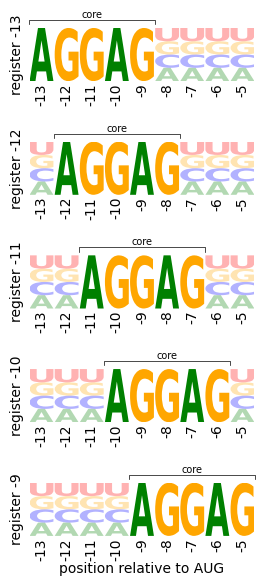

In [5]:
fig, subplots = plt.subplots(
    5,
    1,
    figsize=(2.75, 6),
)

print("Plot probability distributions")
for axes, (p, position), pi_lc in zip(subplots, enumerate(positions), gauges):
    pi_lc = pd.DataFrame(pi_lc, columns=alphabet)
    logo = logomaker.Logo(pi_lc, ax=axes, show_spines=False, baseline_width=0)
    
    # Add bracket and "Core" label above the AGGAG motif
    bracket_y = 1.15
    text_y = 1.15
    x_left = p - 0.5
    x_right = p + 4 + 0.5

    # Draw bracket: horizontal line with small vertical ends
    axes.plot([x_left, x_left, x_right, x_right], 
                [bracket_y - 0.08, bracket_y, bracket_y, bracket_y - 0.08], 
                color='black', linewidth=0.5, clip_on=False)

    # Add "Core" label
    axes.text((x_left + x_right) / 2, text_y, 'core', 
                ha='center', va='bottom', fontsize=7, clip_on=False)

    axes.set(
        ylim=(0, 1),
        yticks=[], #(0, 1),
        yticklabels=[], #["0", "1"],
        ylabel=f"register {position}",
        xticks=np.arange(9),
        xticklabels=np.arange(-13, -4),
    )
    axes.tick_params(axis='x', rotation=90, length=0, pad=1.5)  # xtick marks of length 0
    axes.tick_params(axis='y', length=2)
    if position == -9:  # Use 'position' instead of 'p'
        axes.set_xlabel("position relative to AUG", labelpad=1)
    # Hide the x-axis line but keep the xtick labels
    axes.spines['bottom'].set_visible(False)

    for p in list(range(p)) + list(range(p + 5, 9)):
        for c in alphabet:
            logo.style_single_glyph(p, c, alpha=0.3)

fig.tight_layout(h_pad=1, w_pad=0)

### Computing gauge-fixed parameters

Once we have defined the probability distributions capturing the sequences of interest at the different fitness peaks, we compute the gauge-fixed parameters under the hierarchical gauges defined by these probability distributions

In [6]:
thetas = {}
for position, pi_lc in zip(positions, gauges):
    theta_fixed = model.get_fixed_params(gauge="hierarchical", pi_lc=pi_lc)
    thetas[position] = theta_fixed
thetas = pd.DataFrame(thetas)
thetas["orbit"] = [x[0] for x in thetas.index]
thetas["subseq"] = [x[1] for x in thetas.index]
thetas

,-13,-12,-11,-10,-9,orbit,subseq
"((), )",1.861897,2.186185,2.211720,1.906598,1.101074,(),
"((0,), A)",0.000000,0.125384,0.225124,0.180145,0.095675,"(0,)",A
"((0,), C)",-0.646397,-0.382700,-0.500224,-0.274297,-0.256858,"(0,)",C
"((0,), G)",0.149598,0.049337,0.161530,-0.020173,0.140285,"(0,)",G
"((0,), U)",0.000753,0.207979,0.113571,0.114324,0.020898,"(0,)",U
...,...,...,...,...,...,...,...
"((0, 1, 2, 3, 4, 5, 6, 7, 8), UUUUUUUGU)",0.104381,-0.015834,0.085375,0.000000,0.019661,"(0, 1, 2, 3, 4, 5, 6, 7, 8)",UUUUUUUGU
"((0, 1, 2, 3, 4, 5, 6, 7, 8), UUUUUUUUA)",0.020460,0.006739,0.019462,0.061911,0.009043,"(0, 1, 2, 3, 4, 5, 6, 7, 8)",UUUUUUUUA
"((0, 1, 2, 3, 4, 5, 6, 7, 8), UUUUUUUUC)",0.049570,0.081591,0.018703,0.046591,-0.016188,"(0, 1, 2, 3, 4, 5, 6, 7, 8)",UUUUUUUUC
"((0, 1, 2, 3, 4, 5, 6, 7, 8), UUUUUUUUG)",-0.027452,-0.080011,0.024590,0.010537,0.000000,"(0, 1, 2, 3, 4, 5, 6, 7, 8)",UUUUUUUUG


As we want to compare the local sequence requirements in the core motif at each register, we need to align the gauge-fixed parameters of the core positions across the different positions, which we do as follows

In [7]:
theta_aligned = {}
orbits = get_subsets_of_set((0, 1, 2, 3, 4))
features = get_orbits_features(orbits, model.alphabet_list)
for p, position in enumerate(positions):
    features_p = [
        (tuple(x + p for x in orbit), subseq) for orbit, subseq in features
    ]
    theta_p = thetas.loc[features_p, position]
    theta_p.index = features
    theta_aligned[position] = theta_p
theta_aligned = pd.DataFrame(theta_aligned)
theta_aligned["orbit"] = [x[0] for x in theta_aligned.index]
theta_aligned["subseq"] = [x[1] for x in theta_aligned.index]
theta_aligned["k"] = [len(x) for x in theta_aligned["subseq"]]
theta_aligned


,-13,-12,-11,-10,-9,orbit,subseq,k
"((), )",1.861897,2.186185,2.211720,1.906598,1.101074,(),,0
"((0,), A)",0.000000,0.000000,0.000000,0.000000,0.000000,"(0,)",A,1
"((0,), C)",-0.646397,-0.966215,-0.780846,-0.678776,-0.501391,"(0,)",C,1
"((0,), G)",0.149598,-0.152077,-0.269654,-0.416939,-0.221410,"(0,)",G,1
"((0,), U)",0.000753,-0.699675,-0.522361,-0.472846,-0.368357,"(0,)",U,1
...,...,...,...,...,...,...,...,...
"((0, 1, 2, 3, 4), UUUGU)",-0.036878,-0.095886,0.384084,0.153701,-0.012828,"(0, 1, 2, 3, 4)",UUUGU,5
"((0, 1, 2, 3, 4), UUUUA)",0.222282,-0.106347,0.074687,0.016267,-0.060240,"(0, 1, 2, 3, 4)",UUUUA,5
"((0, 1, 2, 3, 4), UUUUC)",0.040322,-0.345761,-0.079473,-0.121644,-0.042035,"(0, 1, 2, 3, 4)",UUUUC,5
"((0, 1, 2, 3, 4), UUUUG)",0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 1, 2, 3, 4)",UUUUG,5


### Visualizing gauge-fixed parameters across binding positions

Next, we summarize the local sequence requirements by visualizing the constant, additive and pairwise coefficients in the core positions across the different gauges.

We start by simply visualizing the average fitness of sequences having the core AGGAG motif at different positions by plotting the constant term under each gauge and comparing it with the average fitness in the whole landscape and the fitness of the wild-type sequence AAGGAGGUG.

In [8]:
theta0 = theta_aligned.loc[theta_aligned["k"] == 0, :].copy()
theta0

,-13,-12,-11,-10,-9,orbit,subseq,k
"((), )",1.861897,2.186185,2.21172,1.906598,1.101074,(),,0


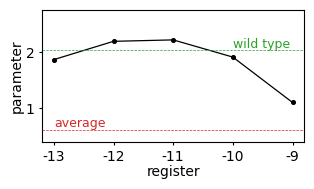

In [9]:
mean_f = function.values.mean()
wt_f = function.loc["AAGGAGGUG"].values[0]

mean_color = "C3"
cons_color = "C2"
fig, ax = plt.subplots(1, 1, figsize=(3, 1.75))
means = theta0[positions].values.flatten()
ax.scatter(positions, means, c="black", s=7)
ax.plot(positions, means, c="black", lw=0.9)
ax.axhline(mean_f, c=mean_color, linestyle="--", lw=0.5)
ax.axhline(wt_f, c=cons_color, linestyle="--", lw=0.5)
ax.set(
    xticks=positions,  # Set ticks BEFORE ticklabels
    xticklabels=positions,
    ylim=(0.4, 2.75),
)
ax.text(x=-10, y=wt_f, s="wild type", fontsize=9, ha="left", va="bottom", color=cons_color)
ax.text(x=-13, y=mean_f, s="average", fontsize=9, ha="left", va="bottom", color=mean_color)
ax.tick_params(axis='both', which='major', length=2)
ax.set_xlabel("register", labelpad=1)
ax.set_ylabel("parameter", labelpad=1)
fig.tight_layout(pad=0.2)


This shows that the optimal position of the AGGAG motif relative to the start codon in the dmsC gene is at registers -12 and -11, and fitness drops dramatically when the motif is located at position -9. 

Next, we visualize the additive coefficients around each fitness peak at the core positions

In [10]:
theta_add = theta_aligned.loc[theta_aligned["k"] == 1, :].copy()
theta_add["position"] = [x[0]+1 for x in theta_add["orbit"]]
theta_lc_positions = {
    position: pd.pivot(
        theta_add, index="subseq", columns="position", values=position
    )
    for position in positions
}

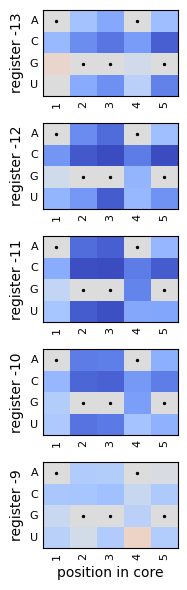

In [21]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(2, 6),
)

for ax, (position, theta_lc) in zip(axes, theta_lc_positions.items()):
    # Invert the y-axis order so lower y values are at the top
    sns.heatmap(
        theta_lc.iloc[::-1, :],  # reverse rows for y-axis inversion
        ax=ax,
        cmap="coolwarm",
        center=0,
        cbar=False,
        vmin=-1.5,
        vmax=1.5,
    )
    xs = np.arange(5)
    ys = np.array([0, 2, 2, 0, 2])
    # Adjust scatter y positions to match inverted y-axis
    ax.scatter(xs + 0.5, (3 - ys) + 0.5, c="black", s=2)
    ax.set(
        ylabel=f"register {position}",
        xlabel="",
        aspect=.8,
        ylim=(0, 4),   # 4 rows (ACGU): still needed for axis scaling, y inverted by data order
        xlim=(0, 5),   # 5 columns (positions 1-5)
    )
    # Keep yticklabels in same logical order (e.g., ACGU mapped to 0,1,2,3 originally)
    # But now since the DataFrame is inverted, flip the order of ticklabels
    ax.set_yticks(np.arange(4)+0.5, labels=list('ACGU')[::-1], rotation=0, fontsize=8)
    ax.set_xticks(np.arange(5)+0.5, labels=np.arange(1, 6), rotation=90, fontsize=8)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)
    sns.despine(ax=ax, top=False, right=False)
ax.set(xlabel="position in core")
fig.tight_layout()


These heatmaps show that mutations away from the canonical AGGAG motif are deleterious across all registers, but also that their quantitative effects are very similar to each other.

Next, we investigate whether the same applies to the pairwise coefficients

In [12]:
pos_alleles = [f"{p}{a}" for p, a in product(range(5), alphabet)]
theta_pw = theta_aligned.loc[theta_aligned["k"] == 2, :].copy()
theta_pw["pos_allele_1"] = [
    f"{orbit[0]}{subseq[0]}"
    for orbit, subseq in theta_pw[["orbit", "subseq"]].values
]
theta_pw["pos_allele_2"] = [
    f"{orbit[1]}{subseq[1]}"
    for orbit, subseq in theta_pw[["orbit", "subseq"]].values
]

theta_lclc_positions = {
    position: pd.pivot(
        theta_pw,
        index="pos_allele_1",
        columns="pos_allele_2",
        values=position,
    )
    .reindex(pos_alleles)
    .T.reindex(pos_alleles)
    .T
    for position in positions
}

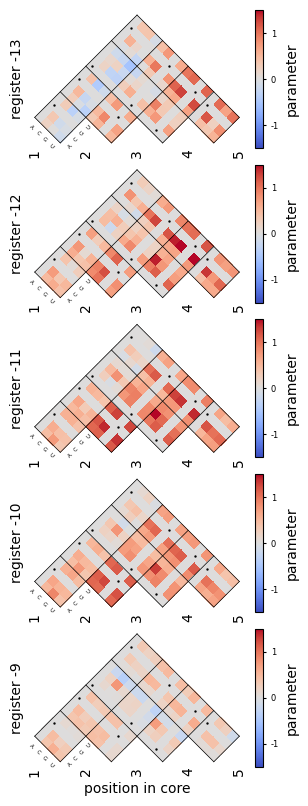

In [22]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(3, 8),
)

for ax, (position, theta_lclc) in zip(
    axes, theta_lclc_positions.items()
):
    theta_lclc = theta_lclc.to_numpy().reshape(5, 4, 5, 4)
    ax, cbar = heatmap_pairwise(
        theta_lclc,
        alphabet=alphabet,
        seq="AGGAG",
        ax=ax,
        clim=(-1.5, 1.5),
        ccenter=0,
        sepline_kwargs={"lw": 0.5, "c": "black"},
        show_alphabet=True,
        show_position=False,
        alphabet_size=4,
        cmap_size="4%",
    )
    cbar.set_ticks([-1.0, 0.0, 1.0], 
                    labels=["-1", "0", "1"], 
                    size=0,  # Turn off major tick length
                    minor=False, 
                    fontsize=6)
    # Set cbar tick_params to half the default length (default is 4.0, so use 2.0)
    cbar.ax.tick_params(length=2)  # halve the tick length
    cbar.set_label(r"parameter")
    ax.set_xticklabels(np.arange(1, 6))
    ax.tick_params(axis='x', length=0, rotation=90, pad=0.5)
    ax.set(ylabel=f"register {position}")
ax.set(xlabel="position in core")

fig.tight_layout(h_pad=0.5, w_pad=1.0, pad=0.5)

These heatmaps show that the pairwise coefficients describing the interactions between pairs of core positions are also very similar across the different registers. Overall, these results support the hypothesis that the different peaks correspond to binding of the same element at different distances from the start codon.

Finally, we quantitatively compare the values of these parameters across the different registers

Plotting comparison of coefficients


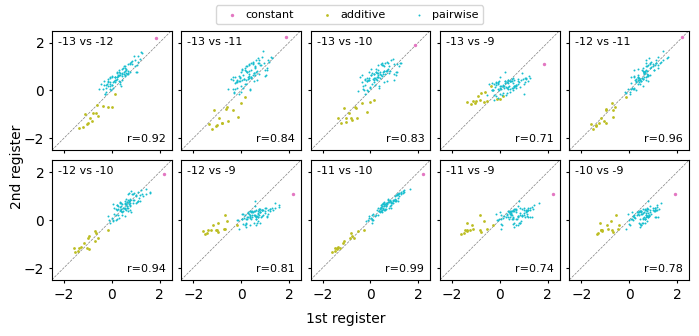

In [14]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(7, 3.25),
    sharey=True,
    sharex=True
)

print("Plotting comparison of coefficients")
pos_pairs = list(combinations(positions, 2))
theta_up_to_pw = theta_aligned.loc[theta_aligned["k"] <= 2, :]
idx = ~np.all(theta_up_to_pw[positions].values == 0.0, axis=1)
theta_up_to_pw = theta_up_to_pw.loc[idx, :]

lims = (-2.5, 2.5)
sizes = [6, 4, 2]
lables = ["constant", "additive", "pairwise"]
palette = {0: "C6", 1: "C8", 2: "C9"}

for (p, q), ax in zip(pos_pairs, axes.flatten()):           
    for k, theta_k in theta_up_to_pw.groupby("k"):
        ax.scatter(
            theta_k[p],
            theta_k[q],
            c=palette[k],
            s=sizes[k],
            lw=0,
            label=lables[k],
        )
    ax.axline((0, 0), slope=1, lw=0.5, linestyle="--", c="grey", zorder=-100)
    ax.set(aspect="equal", xlim=lims, ylim=lims)
    ax.set_xticks([-2,0,2])
    ax.set_yticks([-2,0,2])
    ax.tick_params(axis='both', which='major', length=2)
    ax.tick_params(axis='both', which='minor', length=2)

    ax.text(
        0.05,
        0.95,
        f"{p} vs {q}",
        fontsize=8,
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    r = pearsonr(theta_up_to_pw[p], theta_up_to_pw[q])[0]
    ax.text(
        0.95,
        0.05,
        "r={:.2f}".format(r),
        fontsize=8,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
    )
    
fig.supylabel('2nd register', fontsize=10)
fig.supxlabel("1st register", fontsize=10)
fig.tight_layout(h_pad=0.5, w_pad=0.5, pad=0.5)
fig.subplots_adjust(top=0.95)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=8,
    frameon=True,
    handletextpad=0.2,           # reduce space between symbol and text
)